# Generadores de Variables Aleatorias — Simulación de Llegadas y Compras de Clientes

Este notebook valida, de forma empírica, los tres generadores implementados en el motor de Rust
(`random_engine`, expuesto a Python vía `pyo3`):

1. **Proceso de Poisson** para las llegadas de clientes (tiempos entre llegadas vía **Transformada Inversa** sobre la exponencial).
2. **Método de Composición** para la cantidad comprada por cliente (mezcla 90% regular / 10% mayorista).
3. **Comparación rigurosa** entre Transformada Inversa y Aceptación-Rechazo para la cantidad del cliente regular.

Para cada generador se valida media, varianza y bondad de ajuste (Chi-cuadrado) contra la distribución
teórica declarada, y se cierra con una comparación cuantitativa de eficiencia entre Inversa y Rechazo.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

import random_engine as re

re.set_seed(123)  # misma semilla que simulation/config.py: resultados reproducibles
np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

resumen = []  # aquí se acumula la tabla de validación estadística de la sección 4

## 1. Proceso de Poisson — llegadas de clientes



In [2]:
# Llegadas de clientes por dia, una tasa por franquicia (ver simulation/config.py)
lambdas_llegadas = {"Miraflores": 80.0, "Oakland": 50.0, "UVG": 120.0}
N1 = 20_000

muestras_llegadas = {}
for nombre, lam in lambdas_llegadas.items():
    t_entre_llegadas = np.array([re.poisson_arrival(lam) for _ in range(N1)])
    muestras_llegadas[nombre] = t_entre_llegadas

    media_obs, var_obs = t_entre_llegadas.mean(), t_entre_llegadas.var(ddof=1)
    media_teo, var_teo = 1 / lam, 1 / lam**2
    print(
        f"[{nombre:10s}] lambda={lam:5.0f}/dia | "
        f"media obs={media_obs:.5f} teo={media_teo:.5f} | "
        f"var obs={var_obs:.5f} teo={var_teo:.5f}"
    )

# Miraflores como caso representativo para el resto de la seccion 1
lambda_llegadas = lambdas_llegadas["Miraflores"]
t_entre_llegadas = muestras_llegadas["Miraflores"]

[Miraflores] lambda=   80/dia | media obs=0.01241 teo=0.01250 | var obs=0.00015 teo=0.00016
[Oakland   ] lambda=   50/dia | media obs=0.02006 teo=0.02000 | var obs=0.00040 teo=0.00040
[UVG       ] lambda=  120/dia | media obs=0.00840 teo=0.00833 | var obs=0.00007 teo=0.00007


In [3]:
# Bondad de ajuste (Chi-cuadrado) con bins de igual probabilidad bajo Exponencial(lambda)
k_bins = 15
for nombre, lam in lambdas_llegadas.items():
    muestra = muestras_llegadas[nombre]
    bordes = stats.expon(scale=1 / lam).ppf(np.linspace(0, 1, k_bins + 1))
    bordes[-1] = np.inf

    obs, _ = np.histogram(muestra, bins=bordes)
    esp = np.full(k_bins, N1 / k_bins)

    chi2_stat, p_valor = stats.chisquare(obs, esp)
    veredicto = "No se rechaza H0" if p_valor > 0.05 else "Se rechaza H0"
    print(f"[{nombre:10s}] Chi-cuadrado = {chi2_stat:7.3f} (gl={k_bins - 1}), "
          f"p-valor = {p_valor:.4f}  ->  {veredicto} (Exponencial)")

    resumen.append({
        "generador": f"Llegadas (Inversa) - {nombre}",
        "distribución": f"Exp(λ={lam:.0f}/dia)",
        "N": N1,
        "media_obs": muestra.mean(), "media_teo": 1 / lam,
        "var_obs": muestra.var(ddof=1), "var_teo": 1 / lam**2,
        "chi2": chi2_stat, "p_valor": p_valor,
    })

[Miraflores] Chi-cuadrado =  14.215 (gl=14), p-valor = 0.4338  ->  No se rechaza H0 (Exponencial)
[Oakland   ] Chi-cuadrado =   6.076 (gl=14), p-valor = 0.9645  ->  No se rechaza H0 (Exponencial)
[UVG       ] Chi-cuadrado =  12.144 (gl=14), p-valor = 0.5948  ->  No se rechaza H0 (Exponencial)


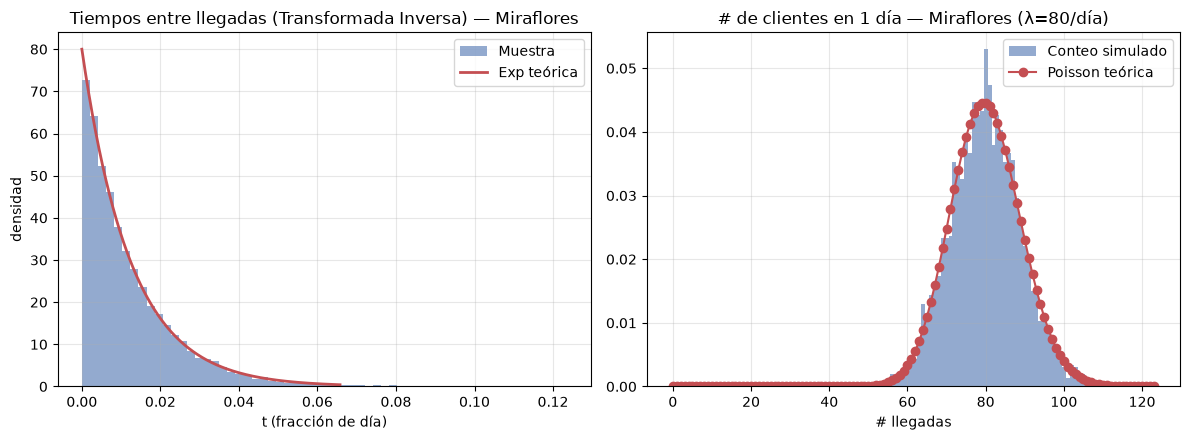

Media conteo llegadas/dia: obs=80.062  teo=80.000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x = np.linspace(0, np.percentile(t_entre_llegadas, 99.5), 300)
axes[0].hist(t_entre_llegadas, bins=60, density=True, alpha=0.6, color="#4C72B0", label="Muestra")
axes[0].plot(x, stats.expon(scale=1 / lambda_llegadas).pdf(x), color="#C44E52", lw=2, label="Exp teórica")
axes[0].set_title("Tiempos entre llegadas (Transformada Inversa) — Miraflores")
axes[0].set_xlabel("t (fracción de día)")
axes[0].set_ylabel("densidad")
axes[0].legend()

# Validación cruzada: acumular tiempos entre llegadas -> conteo de llegadas en un dia completo
ventana = 1.0  # dia completo, igual que generadores.tiempos_de_llegada(horizonte=1.0)
n_simulaciones = 3000
conteos = []
for _ in range(n_simulaciones):
    ts = np.cumsum(np.array([re.poisson_arrival(lambda_llegadas) for _ in range(200)]))
    conteos.append(np.sum(ts <= ventana))
conteos = np.array(conteos)

k_max = conteos.max()
ks = np.arange(0, k_max + 1)
axes[1].hist(conteos, bins=np.arange(-0.5, k_max + 1.5, 1), density=True, alpha=0.6,
             color="#4C72B0", label="Conteo simulado")
axes[1].plot(ks, stats.poisson(mu=lambda_llegadas * ventana).pmf(ks), "o-", color="#C44E52",
             label="Poisson teórica")
axes[1].set_title(f"# de clientes en {ventana:.0f} día — Miraflores (λ={lambda_llegadas:.0f}/día)")
axes[1].set_xlabel("# llegadas")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Media conteo llegadas/dia: obs={conteos.mean():.3f}  teo={lambda_llegadas*ventana:.3f}")

## 2. Método de Composición — cantidad comprada por cliente


In [5]:
# Tasas del proyecto: TASA_REGULAR = 1/2 (media 2 brownies), TASA_MAYORISTA = 1/20 (media 20 brownies)
lambda_reg = 0.5   # cantidad media regular = 2 brownies
lambda_may = 0.05  # cantidad media mayorista = 20 brownies
N2 = 20_000

muestras = [re.customer_quantity(lambda_reg, lambda_may) for _ in range(N2)]
cantidades = np.array([q for q, _ in muestras])
es_mayorista = np.array([w for _, w in muestras])

p_mayorista_obs = es_mayorista.mean()
print(f"Proporción mayorista observada: {p_mayorista_obs:.4f}  (teórica: 0.10)")

test_binom = stats.binomtest(int(es_mayorista.sum()), N2, p=0.10)
print(f"Prueba binomial de la proporción -> p-valor = {test_binom.pvalue:.4f}")

Proporción mayorista observada: 0.1003  (teórica: 0.10)
Prueba binomial de la proporción -> p-valor = 0.8875


In [6]:
cant_reg = cantidades[~es_mayorista]
cant_may = cantidades[es_mayorista]

def validar_subpoblacion(nombre, muestra, lam):
    media_obs, var_obs = muestra.mean(), muestra.var(ddof=1)
    media_teo, var_teo = 1 / lam, 1 / lam**2

    k_bins = 10
    bordes = stats.expon(scale=1 / lam).ppf(np.linspace(0, 1, k_bins + 1))
    bordes[-1] = np.inf
    obs, _ = np.histogram(muestra, bins=bordes)
    esp = np.full(k_bins, len(muestra) / k_bins)
    chi2_stat, p_valor = stats.chisquare(obs, esp)

    print(f"[{nombre}] media obs={media_obs:.4f} teo={media_teo:.4f} | "
          f"var obs={var_obs:.4f} teo={var_teo:.4f} | chi2={chi2_stat:.3f} p={p_valor:.4f}")

    resumen.append({
        "generador": f"Composición - {nombre}",
        "distribución": f"Exp(λ={lam})",
        "N": len(muestra),
        "media_obs": media_obs, "media_teo": media_teo,
        "var_obs": var_obs, "var_teo": var_teo,
        "chi2": chi2_stat, "p_valor": p_valor,
    })

validar_subpoblacion("regular", cant_reg, lambda_reg)
validar_subpoblacion("mayorista", cant_may, lambda_may)

media_mezcla_teo = 0.9 / lambda_reg + 0.1 / lambda_may
media_mezcla_obs = cantidades.mean()
print(f"\nMedia de la mezcla completa: obs={media_mezcla_obs:.4f}  teo={media_mezcla_teo:.4f}")

[regular] media obs=1.9834 teo=2.0000 | var obs=3.8090 teo=4.0000 | chi2=1.425 p=0.9977
[mayorista] media obs=19.9359 teo=20.0000 | var obs=386.9846 teo=400.0000 | chi2=11.089 p=0.2697

Media de la mezcla completa: obs=3.7840  teo=3.8000


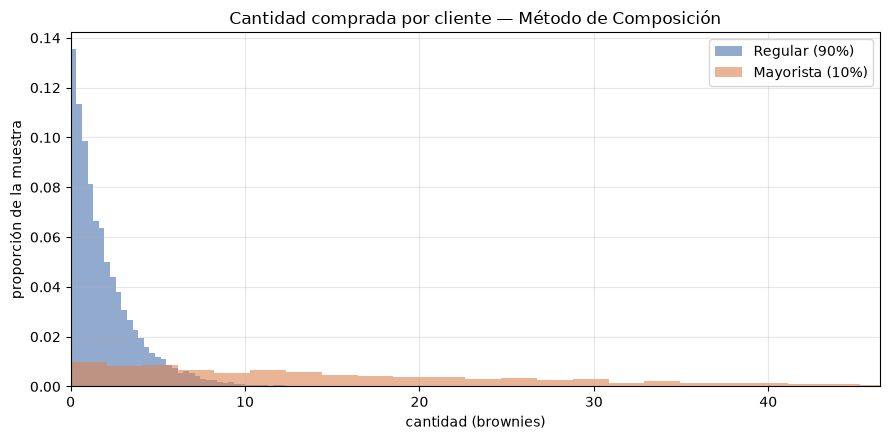

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(cant_reg, bins=60, density=False, weights=np.full(len(cant_reg), 1 / N2),
        alpha=0.6, color="#4C72B0", label="Regular (90%)")
ax.hist(cant_may, bins=60, density=False, weights=np.full(len(cant_may), 1 / N2),
        alpha=0.6, color="#DD8452", label="Mayorista (10%)")
ax.set_title("Cantidad comprada por cliente — Método de Composición")
ax.set_xlabel("cantidad (brownies)")
ax.set_ylabel("proporción de la muestra")
ax.set_xlim(0, np.percentile(cantidades, 99))
ax.legend()
plt.tight_layout()
plt.show()

## 3. Comparación rigurosa: Transformada Inversa vs. Aceptación-Rechazo


In [8]:
lambda_3 = lambda_reg  # misma tasa que el cliente regular de la sección 2
N3 = 20_000

t0 = time.perf_counter()
muestras_inv = np.array([re.regular_quantity_inverse(lambda_3) for _ in range(N3)])
t_inv_N3 = time.perf_counter() - t0

t0 = time.perf_counter()
resultados_ar = [re.regular_quantity_accept_reject(lambda_3) for _ in range(N3)]
t_ar_N3 = time.perf_counter() - t0

muestras_ar = np.array([v for v, _ in resultados_ar])
intentos_ar = np.array([a for _, a in resultados_ar])

tasa_aceptacion_obs = N3 / intentos_ar.sum()
print(f"Tasa de aceptación observada: {tasa_aceptacion_obs:.4f}  (teórica: 0.50)")
print(f"Intentos promedio por muestra aceptada: {intentos_ar.mean():.4f}  (teórico: 2.00)")

Tasa de aceptación observada: 0.4984  (teórica: 0.50)
Intentos promedio por muestra aceptada: 2.0065  (teórico: 2.00)


In [9]:
def validar_metodo(nombre, muestra, lam):
    media_obs, var_obs = muestra.mean(), muestra.var(ddof=1)
    media_teo, var_teo = 1 / lam, 1 / lam**2

    k_bins = 15
    bordes = stats.expon(scale=1 / lam).ppf(np.linspace(0, 1, k_bins + 1))
    bordes[-1] = np.inf
    obs, _ = np.histogram(muestra, bins=bordes)
    esp = np.full(k_bins, len(muestra) / k_bins)
    chi2_stat, p_valor = stats.chisquare(obs, esp)

    print(f"[{nombre}] media obs={media_obs:.4f} teo={media_teo:.4f} | "
          f"var obs={var_obs:.4f} teo={var_teo:.4f} | chi2={chi2_stat:.3f} p={p_valor:.4f}")

    resumen.append({
        "generador": nombre,
        "distribución": f"Exp(λ={lam})",
        "N": len(muestra),
        "media_obs": media_obs, "media_teo": media_teo,
        "var_obs": var_obs, "var_teo": var_teo,
        "chi2": chi2_stat, "p_valor": p_valor,
    })

validar_metodo("Cantidad regular (Inversa)", muestras_inv, lambda_3)
validar_metodo("Cantidad regular (Rechazo)", muestras_ar, lambda_3)

test_acept = stats.binomtest(N3, int(intentos_ar.sum()), p=0.5)
print(f"\nPrueba binomial tasa de aceptación (H0: p=0.5) -> p-valor = {test_acept.pvalue:.4f}")

[Cantidad regular (Inversa)] media obs=1.9872 teo=2.0000 | var obs=3.9932 teo=4.0000 | chi2=9.948 p=0.7660
[Cantidad regular (Rechazo)] media obs=2.0174 teo=2.0000 | var obs=4.1366 teo=4.0000 | chi2=7.773 p=0.9008

Prueba binomial tasa de aceptación (H0: p=0.5) -> p-valor = 0.5196


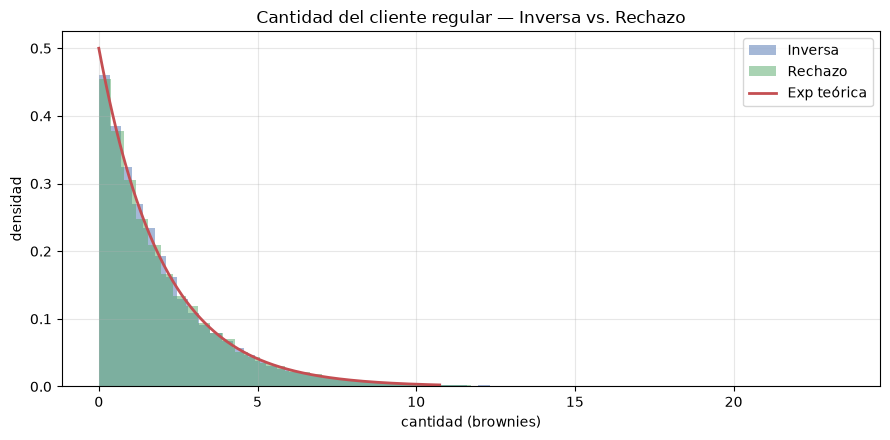

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.linspace(0, np.percentile(muestras_inv, 99.5), 300)
ax.hist(muestras_inv, bins=60, density=True, alpha=0.5, color="#4C72B0", label="Inversa")
ax.hist(muestras_ar, bins=60, density=True, alpha=0.5, color="#55A868", label="Rechazo")
ax.plot(x, stats.expon(scale=1 / lambda_3).pdf(x), color="#C44E52", lw=2, label="Exp teórica")
ax.set_title("Cantidad del cliente regular — Inversa vs. Rechazo")
ax.set_xlabel("cantidad (brownies)")
ax.set_ylabel("densidad")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Validación estadística consolidada


In [11]:
df_resumen = pd.DataFrame(resumen)
df_resumen["error_media_%"] = 100 * (df_resumen.media_obs - df_resumen.media_teo).abs() / df_resumen.media_teo
df_resumen["error_var_%"] = 100 * (df_resumen.var_obs - df_resumen.var_teo).abs() / df_resumen.var_teo
df_resumen["pasa_chi2 (α=0.05)"] = df_resumen.p_valor > 0.05
df_resumen.round(4)

,generador,distribución,N,media_obs,media_teo,var_obs,var_teo,chi2,p_valor,error_media_%,error_var_%,pasa_chi2 (α=0.05)
0,Llegadas (Inversa) - Miraflores,Exp(λ=80/dia),20000,0.0124,0.0125,0.0002,0.0002,14.2150,0.4338,0.7213,3.1165,True
1,Llegadas (Inversa) - Oakland,Exp(λ=50/dia),20000,0.0201,0.0200,0.0004,0.0004,6.0760,0.9645,0.3043,0.6250,True
2,Llegadas (Inversa) - UVG,Exp(λ=120/dia),20000,0.0084,0.0083,0.0001,0.0001,12.1435,0.5948,0.7462,1.8791,True
3,Composición - regular,Exp(λ=0.5),17994,1.9834,2.0000,3.8090,4.0000,1.4251,0.9977,0.8322,4.7758,True
4,Composición - mayorista,Exp(λ=0.05),2006,19.9359,20.0000,386.9846,400.0000,11.0887,0.2697,0.3203,3.2538,True
5,Cantidad regular (Inversa),Exp(λ=0.5),20000,1.9872,2.0000,3.9932,4.0000,9.9475,0.7660,0.6414,0.1710,True
6,Cantidad regular (Rechazo),Exp(λ=0.5),20000,2.0174,2.0000,4.1366,4.0000,7.7725,0.9008,0.8676,3.4160,True


## 5. Comparación cuantitativa: Inversa vs. Rechazo

Se mide el tiempo de generación de $N$ muestras con cada método y se cuantifica el número de candidatos
generados/descartados por el método de Rechazo.

In [12]:
N5 = 50_000

t0 = time.perf_counter()
_ = [re.regular_quantity_inverse(lambda_3) for _ in range(N5)]
t_inversa = time.perf_counter() - t0

t0 = time.perf_counter()
resultados_5 = [re.regular_quantity_accept_reject(lambda_3) for _ in range(N5)]
t_rechazo = time.perf_counter() - t0

intentos_5 = np.array([a for _, a in resultados_5])
candidatos_generados = intentos_5.sum()
candidatos_descartados = candidatos_generados - N5

print(f"N = {N5:,} muestras aceptadas en ambos métodos\n")
print(f"Tiempo Inversa : {t_inversa:.4f} s  ->  {N5 / t_inversa:,.0f} muestras/s")
print(f"Tiempo Rechazo : {t_rechazo:.4f} s  ->  {N5 / t_rechazo:,.0f} muestras/s")
print(f"Rechazo / Inversa (tiempo): {t_rechazo / t_inversa:.2f}x más lento\n")
print(f"Candidatos generados (Rechazo)  : {candidatos_generados:,}")
print(f"Candidatos descartados (Rechazo): {candidatos_descartados:,}  "
      f"({100 * candidatos_descartados / candidatos_generados:.2f}% del total generado)")

N = 50,000 muestras aceptadas en ambos métodos

Tiempo Inversa : 0.0240 s  ->  2,085,031 muestras/s
Tiempo Rechazo : 0.0537 s  ->  931,064 muestras/s
Rechazo / Inversa (tiempo): 2.24x más lento

Candidatos generados (Rechazo)  : 100,378
Candidatos descartados (Rechazo): 50,378  (50.19% del total generado)


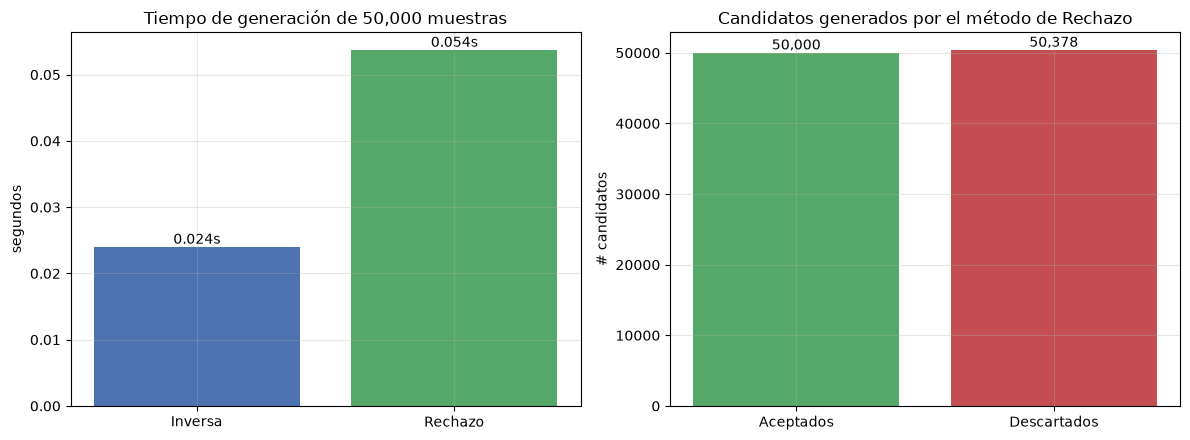

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(["Inversa", "Rechazo"], [t_inversa, t_rechazo], color=["#4C72B0", "#55A868"])
axes[0].set_ylabel("segundos")
axes[0].set_title(f"Tiempo de generación de {N5:,} muestras")
for i, v in enumerate([t_inversa, t_rechazo]):
    axes[0].text(i, v, f"{v:.3f}s", ha="center", va="bottom")

axes[1].bar(["Aceptados", "Descartados"], [N5, candidatos_descartados],
            color=["#55A868", "#C44E52"])
axes[1].set_title("Candidatos generados por el método de Rechazo")
axes[1].set_ylabel("# candidatos")
for i, v in enumerate([N5, candidatos_descartados]):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()